In [ ]:
!git clone https://github.com/baudm/parseq.git
!git clone https://github.com/roatienza/deep-text-recognition-benchmark.git
!git clone https://github.com/Topdu/OpenOCR.git
!git clone https://github.com/simplify23/CDistNet.git

Cloning into 'Signboard-Text-Detection-and-Recognition-in-Streaming-Video'...
remote: Enumerating objects: 368, done.
remote: Counting objects: 100% (368/368), done.
remote: Compressing objects: 100% (286/286), done.
remote: Total 368 (delta 78), reused 354 (delta 65), pack-reused 0 (from 0)
Receiving objects: 100% (368/368), 27.29 MiB | 26.75 MiB/s, done.
Resolving deltas: 100% (78/78), done.
Cloning into 'parseq'...
remote: Enumerating objects: 612, done.
remote: Counting objects: 100% (312/312), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 612 (delta 241), reused 192 (delta 192), pack-reused 300 (from 2)
Receiving objects: 100% (612/612), 1.34 MiB | 20.42 MiB/s, done.
Resolving deltas: 100% (343/343), done.
Cloning into 'deep-text-recognition-benchmark'...
remote: Enumerating objects: 1922, done.
remote: Counting objects: 100% (188/188), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 1922 (delta 135), reused 150 (delta 101), pack-reuse

In [2]:
!pip install -q lmdb pillow tqdm gdown unidecode fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.1/295.1 kB 8.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 16.0 MB/s eta 0:00:00


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch
import os
import cv2
import numpy as np
import json
from collections import defaultdict
from pathlib import Path
from PIL import Image
import gdown
import sys
import random
import string
sys.path.append('/kaggle/working/parseq')
sys.path.append('/kaggle/working/deep-text-recognition-benchmark')
sys.path.append('/kaggle/working/OpenOCR')
sys.path.append('/kaggle/working/CDistNet')
from utils.transforms import convert_box_format, check_and_refine_valid_box
from tqdm import tqdm 
from fvcore.nn import FlopCountAnalysis, parameter_count
from argparse import Namespace 
device = ("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)               # CPU
    torch.cuda.manual_seed(seed)          # GPU
    torch.cuda.manual_seed_all(seed)      # Multi-GPU (nếu có)

    # For deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
class SignboardText(Dataset):
    def __init__(self, image_data, annotation_data, category, transforms=None):
        self.image_data = image_data
        self.category = category

        self.image_list = os.listdir(image_data)
        self.annotation_lookup = self.read_json(annotation_data)
        self.transforms = transforms 

    def read_json(self, file): 
        with open(file, 'r') as file: 
            data = json.load(file)

        # Create mapping: id images and image_id annotations
        annotations_lookup = defaultdict(list)
        for info in data['annotations']:
            annotations_lookup[info['image_id']].append(info)

        return annotations_lookup

    def extract_info(self, info):
        labels = []
        for p in info:
            object = {}
            bbox = p['bbox']
            seg = p['segmentation']
            transcript = p['transcription']

            object['bbox'] = bbox
            object['segmentation'] = seg
            object['transcription'] = transcript

            labels.append(object)

        return labels

    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, index):
        image_name = self.image_list[index]
        image_id = os.path.join(Path(self.image_data).name, image_name)
        image_path = os.path.join(self.image_data, image_name)
        info = self.annotation_lookup.get(image_id)
        if info is not None: labels = self.extract_info(info)
        else: 
            print(image_path)
            labels = None 

        if self.category == 'recognize':
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_height, image_width = image.shape[:2]
            sub_text_image = []
            if labels is not None: 
                for i, label in enumerate(labels): 
                    sub_image = {}
                    bbox = label['bbox']
                    new_bbox = check_and_refine_valid_box(bbox, image_width, image_height)
                    if new_bbox is None: continue
                    xmin, ymin, xmax, ymax = convert_box_format(new_bbox, current_format_box='xywh', output_format_box='xyxy')
                    # Cropped text area in image 
                    text_image = image[ymin:ymax, xmin:xmax]
                    sub_image['original_text'] = text_image
                    transformed_image = None
                    
                    if self.transforms is not None:
                        transformed_image = self.transforms(Image.fromarray(text_image))
                        sub_image['text'] = transformed_image

                    sub_image['transcription'] = label['transcription']

                    sub_text_image.append(sub_image)

            return sub_text_image

In [6]:
import time
MIN_POLYGON_POINT_COUNT = 3
def measure_speed(model, image, num_runs=100):    
    # Warm-up
    with torch.inference_mode():
        for _ in range(10):
            _ = model(image)
    
    # Measure Speed
    torch.cuda.synchronize()
    start = time.time()
    
    with torch.inference_mode():
        for _ in range(num_runs):
            _ = model(image)
            
    torch.cuda.synchronize()
    end = time.time()

    avg_time_ms = ((end - start) / num_runs) * 1000 # miliseconds
    
    return avg_time_ms

def measure_flops(model, image): 
    flops = FlopCountAnalysis(model, image).total() / 1e9
    return flops

def measure_params(model): 
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    non_trainable = sum(p.numel() for p in model.parameters() if not p.requires_grad) / 1e6
    total = trainable + non_trainable

    return total, trainable, non_trainable

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import random
from pathlib import Path
from unidecode import unidecode

def mapping_without_accent(text):
    return unidecode(text)

def plot_prediction(index, prediction, category_save='original', category='accent'): 
    assert category in ['accent', 'without_accent']
    """
    Args: 
        incorrect_prediction: output dictionary after predicting, include: original_text, processed_text, GT, prediction
        category_save: {'original', 'processed'}. processed -> processed image
    Return: 
        Plot list incorrect text image
    
    """
    plt.figure(figsize=(13, 7))
    rows, cols = 3, 3
    for i, idx in enumerate(index): 
        info = prediction[idx]
        original_text, text_image, gt, pred = info['original_text'], info['text'], info['GT'][0], info['Prediction']
        
        title = f'Pred: {pred} | GT: {gt}'
        plt.subplot(rows, cols, i+1)
        if category_save == 'original': plt.imshow(original_text)
        if category_save == 'processed': plt.imshow(text_image)

        if category == 'without_accent':
            pred_wa = mapping_without_accent(pred)
            gt_wa = mapping_without_accent(gt)
            title += f'\nPred: {pred_wa} | GT: {gt_wa} (without_accent)'
        else: 
            pred_wa, gt_wa = pred, gt 

        if pred_wa == gt_wa:
            plt.title(title, fontsize=10, c='g')
        else: 
            plt.title(title, fontsize=10, c='r')
    
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def normalize_text(text, charset=None):
    """
    Normalize text for fair evaluation
    
    Args:
        text: Input text (prediction or ground truth)
        charset: Allowed characters (default: 0-9a-z)
    
    Returns:
        Normalized text
    """
    if charset is None:
        # Default: lowercase alphanumeric only (36 chars)
        charset = string.digits + string.ascii_lowercase
    
    text = text.lower()
    
    allowed_chars = set(charset)
    text = ''.join([c for c in text if c in allowed_chars])
    
    return text

def predict_one_image(model, image, label, method, category='accent', postprocess=None, normalize=True):
    assert category in ['accent', 'without_accent']
    assert isinstance(label, str)
    if postprocess is not None: 
        assert isinstance(postprocess, tuple)
    correct = 0
    
    if method == 'parseq':
        with torch.inference_mode(): 
            logits = model(image)
            pred, confidence = model.tokenizer.decode(logits)
            
    if method == 'vitstr': 
        converter, img2text = postprocess
        assert converter is not None
        assert img2text is not None
        pred = img2text(model, [image], converter)
        
    if method in ['svtrv2', 'smtr']: 
        (post_process_class, ) = postprocess
        assert post_process_class is not None
        with torch.inference_mode():
            logits = model(image)
            post_results = post_process_class(logits,
                                             torch_tensor=True)
            pred, score = post_results[0]
            pred = [pred]
            
    if method == 'cam':
        (converter, ) = postprocess
        assert converter is not None
        with torch.inference_mode(): 
            logits = model((image, None, None, None))['rec_output']
            pred, _ = converter(logits)[0]
            pred = [pred]

    if method == 'cdistnet': 
        (converter, ) = postprocess
        assert converter is not None
        with torch.inference_mode(): 
            all_hyp, _ = model.translate_batch(image)
            pred, _ = converter.decode(np.array(all_hyp[0]))[0]
            pred = [pred]
        
    pred = pred[0]
    if category == 'without_accent': 
        pred_ac = mapping_without_accent(pred)
        label_ac = mapping_without_accent(label)
    else: 
        pred_ac, label_ac = pred, label

    if normalize: 
        pred_ac, label_ac = normalize_text(pred_ac), normalize_text(label_ac)
        
    if pred_ac == label_ac:
        correct += 1

    return pred, correct

def evaluate(dataloader, model, device, method, category='accent', 
             postprocess=None, normalize=True):
    assert category in ['accent', 'without_accent']
    total_samples = 0
    total_correct = 0
    batch_empty = 0
    correct_prediction, incorrect_prediction = [], []
    correct_number, incorrect_number = 0, 0
    print(category)
    
    for batch in tqdm(dataloader): 
        if batch: 
            total_samples += len(batch)
            # Predict for each text image
            for text_image in batch: 
                correct_pred, incorrect_pred = {}, {}
                image, transcript = text_image['text'].to(device), text_image['transcription']
                pred, correct = predict_one_image(model, image, transcript[0], method, category,
                                                 postprocess, normalize)
                total_correct += correct

                if len(text_image['text'].shape) < 4: 

                    if correct == 1 and correct_number < 100: 
                        correct_pred['original_text'] = text_image['original_text'].squeeze().cpu().numpy()
                        correct_pred['text'] = text_image['text'].squeeze(0).permute(1, 2, 0).cpu().numpy() # convert [1, C, W, H] to [W, H ,C]
                        correct_pred['GT'] = transcript
                        correct_pred['Prediction'] = pred
        
                        correct_prediction.append(correct_pred)
                        correct_number += 1
        
                    if correct == 0 and incorrect_number < 100: 
                        incorrect_pred['original_text'] = text_image['original_text'].squeeze().cpu().numpy()
                        incorrect_pred['text'] = text_image['text'].squeeze(0).permute(1, 2, 0).cpu().numpy() # convert [1, C, W, H] to [W, H ,C]
                        incorrect_pred['GT'] = transcript
                        incorrect_pred['Prediction'] = pred
        
                        incorrect_prediction.append(incorrect_pred)
                        incorrect_number += 1
    
        else: 
            batch_empty += 1
            print('batch is empty due to the unlabeled image!')
    
    accuracy = (total_correct / total_samples) * 100

    return accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct

def save_prediction(prediction, path, category_save='original'):
    """
    Args: 
        incorrect_prediction: output dictionary after predicting, include: original_text, processed_text, GT, prediction
        category_save: {'original', 'processed'}. processed -> processed image
    Return: 
        Save list image into a specific folder
    
    """
    if category_save == 'original': save_folder = Path(path)
    if category_save == 'processed': save_folder = Path(path)
    if not save_folder.exists():
        save_folder.mkdir(parents=True, exist_ok=True)
    else: 
        print(f'{save_folder} was existed')

    for i, incorrect in tqdm(enumerate(prediction)): 
        original_text, text_image, gt, pred = incorrect['original_text'], incorrect['text'], incorrect['GT'], incorrect['Prediction']
    
        title = f'Pred: {pred} | GT: {gt[0]}'
        plt.title(title, fontsize=10, c='r')
        try: 
            if category_save == 'original': plt.imshow(original_text)
            if category_save == 'processed': plt.imshow(text_image) 
            plt.axis('off')
            output_path = os.path.join(save_folder, f'prediction_{i}.jpg')
            plt.savefig(output_path)
            plt.close()
        except Exception as e: 
            print(f'Error: {e}')
            pass

### PARSeq

In [8]:
from parseq.strhub.data.module import SceneTextDataModule

In [9]:
parseq = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).eval().to(device)
img_transform = SceneTextDataModule.get_transform(parseq.hparams.img_size)
parseq.hparams

/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/baudm/parseq/zipball/main" to /root/.cache/torch/hub/main.zip
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is fiel

"_convert_":        all
"_target_":         strhub.models.parseq.system.PARSeq
"batch_size":       384
"charset_test":     0123456789abcdefghijklmnopqrstuvwxyz
"charset_train":    0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
"dec_depth":        1
"dec_mlp_ratio":    4
"dec_num_heads":    12
"decode_ar":        True
"dropout":          0.1
"embed_dim":        384
"enc_depth":        12
"enc_mlp_ratio":    4
"enc_num_heads":    6
"img_size":         [32, 128]
"lr":               0.0007
"max_label_length": 25
"name":             parseq
"patch_size":       [4, 8]
"perm_forward":     True
"perm_mirrored":    True
"perm_num":         6
"refine_iters":     1
"warmup_pct":       0.075
"weight_decay":     0.0

In [13]:
viet_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                   category='recognize', 
                                   transforms=img_transform)
english_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                                      annotation_data='/kaggle/input/signboardtext/annotations.json',
                                      category='recognize',
                                      transforms=img_transform)
vin_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin', 
                                  annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                  category='recognize',
                                  transforms=img_transform)

viet_dataloader = DataLoader(dataset=viet_signboardtext, batch_size=1, shuffle=False)
english_dataloader = DataLoader(dataset=english_signboardtext, batch_size=1, shuffle=False)
vin_dataloader = DataLoader(dataset=vin_signboardtext, batch_size=1, shuffle=False)

In [14]:
# Evaluate parseq vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
viet_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(viet_dataloader,
                                                                                                              parseq, 
                                                                                                              device,
                                                                                                              method='parseq',
                                                                                                             category='without_accent')
print(f'Accuracy of vietsignboard: {viet_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard: {total_samples}')
print(f'Total correct of vietsignboard: {total_correct}')
print(f'Total incorrect of vietsignboard: {total_samples - total_correct}')

without_accent


 30%|███       | 359/1194 [03:43<10:53,  1.28it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg
batch is empty due to the unlabeled image!


 40%|███▉      | 475/1194 [04:53<06:19,  1.89it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg
batch is empty due to the unlabeled image!


 52%|█████▏    | 623/1194 [06:32<06:06,  1.56it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [12:40<00:00,  1.57it/s]

Accuracy of vietsignboard: 80.7615601291198
The number of empty batches: 5
Total samples of vietsignboard: 48637
Total correct of vietsignboard: 39280
Total incorrect of vietsignboard: 9357


In [15]:
# Evaluate parseq vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
english_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(english_dataloader,
                                                                                                              parseq, 
                                                                                                              device,
                                                                                                             method='parseq',
                                                                                                             category='without_accent')
print(f'Accuracy of english: {english_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of english: {total_samples}')
print(f'Total correct of english: {total_correct}')
print(f'Total incorrect of english: {total_samples - total_correct}')

without_accent


100%|██████████| 413/413 [01:12<00:00,  5.66it/s]

Accuracy of english: 78.27756445419638
The number of empty batches: 0
Total samples of english: 3646
Total correct of english: 2854
Total incorrect of english: 792


In [16]:
# Evaluate parseq vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
vin_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vin_dataloader,
                                                                                                              parseq, 
                                                                                                              device,
                                                                                                             method='parseq',
                                                                                                             category='without_accent')
print(f'Accuracy of vin: {vin_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vin: {total_samples}')
print(f'Total correct of vin: {total_correct}')
print(f'Total incorrect of vin: {total_samples - total_correct}')

without_accent


100%|██████████| 516/516 [04:16<00:00,  2.02it/s]

Accuracy of vin: 72.95881502890174
The number of empty batches: 0
Total samples of vin: 16608
Total correct of vin: 12117
Total incorrect of vin: 4491


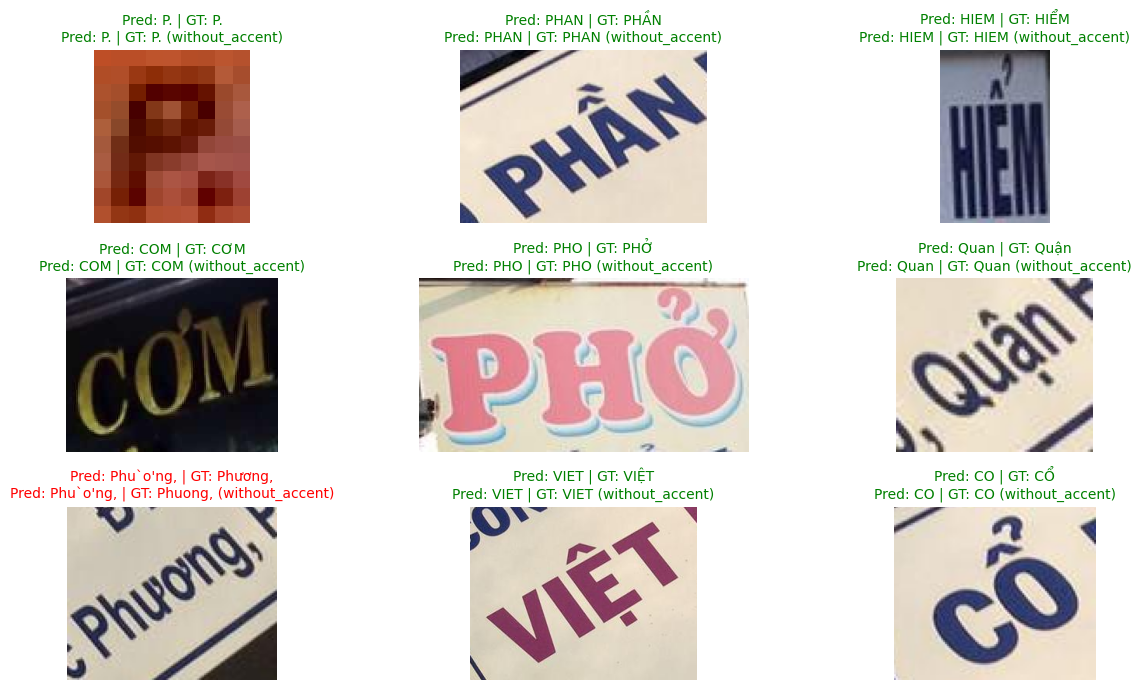

In [ ]:
random.seed(42)
index = random.sample(np.arange(0, len(correct_prediction)).tolist(), k=9)
plot_prediction(index, correct_prediction, category_save='original', category='without_accent')

#### Text-line

In [10]:
vietline_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json', 
                                   category='recognize', 
                                   transforms=img_transform)
vietline_dataloader = DataLoader(dataset=vietline_signboardtext, batch_size=1, shuffle=False)

In [11]:
# Evaluate parseq model on vietsignboard corpus 
set_seed(seed=42) 
vietline_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vietline_dataloader,
                                                                                                              parseq, 
                                                                                                              device,
                                                                                                              method='parseq',
                                                                                                             category='without_accent')
print(f'Accuracy of vietsignboard with text-line: {vietline_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard with text-line: {total_samples}')
print(f'Total correct of vietsignboard with text-line: {total_correct}')
print(f'Total incorrect of vietsignboard with text-line: {total_samples - total_correct}')

without_accent


  3%|▎         | 36/1194 [00:10<04:08,  4.65it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg
batch is empty due to the unlabeled image!


  3%|▎         | 40/1194 [00:12<06:23,  3.01it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg
batch is empty due to the unlabeled image!
/kaggle/input/signboardtext/original_images/vietsignboard/levansy-69.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/languagecenter-1.jpg
batch is empty due to the unlabeled image!


 99%|█████████▉| 1184/1194 [05:18<00:02,  3.36it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [05:21<00:00,  3.72it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg
batch is empty due to the unlabeled image!
Accuracy of vietsignboard with text-line: 59.07762557077626
The number of empty batches: 90
Total samples of vietsignboard with text-line: 10950
Total correct of vietsignboard with text-line: 6469
Total incorrect of vietsignboard with text-line: 4481


In [33]:
set_seed(seed=42)
inputs = next(iter(viet_dataloader))[0]['text'].to(device)
print(f'Input shape: {inputs.shape}')
speed = measure_speed(parseq, inputs)
flops = measure_flops(parseq, inputs)
total_params, trainable_params, non_trainable_params = measure_params(parseq)
print(f'Speed(ms): {speed:.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Input shape: torch.Size([1, 3, 32, 128])
Speed(ms): 12.71
FLOPS: 2.98
Total Params: 23.83
Trainable Params: 23.83
Non Trainable Params: 0.00


### ViTSTR

In [14]:
!pip uninstall timm -y

Found existing installation: timm 1.0.19
Uninstalling timm-1.0.19:
  Successfully uninstalled timm-1.0.19


In [15]:
!pip install -q timm==0.4.5 validators==0.18.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency

In [16]:
from infer_utils import TokenLabelConverter
from modules.vitstr import create_vitstr
from infer import img2text
from torchvision import transforms
from timm.models import create_model
import string

# Open-source 
def get_state_dict(state_dict):
    from collections import OrderedDict
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[14:] # remove module.vitstr.
        new_state_dict[name] = v
    return new_state_dict

In [23]:
class ViTSTRFeatureExtractor:
    def __init__(self, input_channel=1, imgH=224, imgW=224):
        self.imgH = imgH
        self.imgW = imgW
        self.transform = NormalizePAD((input_channel, imgH, imgW))
    
    def __call__(self, img):
        assert isinstance(img, Image.Image)
        img = img.convert('L')
        img = img.resize((self.imgW, self.imgH), Image.BICUBIC)
        img = self.transform(img)
        return img
    
class NormalizePAD:
    def __init__(self, max_size, PAD_type='right'):
        self.toTensor = transforms.ToTensor()
        self.max_size = max_size
        self.max_width_half = max_size[2] // 2 
        self.PAD_type = PAD_type

    def __call__(self, img):
        img = self.toTensor(img)
        img.sub_(0.5).div_(0.5)
        c, h, w = img.size()
        pad_img = torch.FloatTensor(*self.max_size).fill_(0)
        pad_img[:, :, :w] = img  # right pad
        if self.max_size[2] != w:  # add border Pad
            pad_img[:, :, w:] = img[:, :, w - 1].unsqueeze(2).expand(c, h, self.max_size[2] - w)

        return pad_img

In [18]:
# Download model
url_model = 'https://github.com/roatienza/deep-text-recognition-benchmark/releases/download/v0.1.0/vitstr_base_patch16_224_aug.pth'
checkpoint_name = url_model.rsplit('/', 1)[1]
torch.hub.download_url_to_file(url_model, checkpoint_name)

# Load state_dict model
state_dict = torch.load(checkpoint_name, map_location=device)
new_state_dict = get_state_dict(state_dict)

100%|██████████| 326M/326M [00:04<00:00, 72.3MB/s] 


In [24]:
args = Namespace(
    batch_max_length=25,
    character=string.printable[:-6]
)
converter = TokenLabelConverter(args)
num_class = len(converter.character)
extractor = ViTSTRFeatureExtractor()

In [20]:
vitstr_name = 'vitstr_base_patch16_224'
vitstr = create_vitstr(num_tokens=num_class, 
                   model=vitstr_name)
vitstr.load_state_dict(new_state_dict)
vitstr.eval().to(device)

Downloading: "https://dl.fbaipublicfiles.com/deit/deit_base_patch16_224-b5f2ef4d.pth" to /root/.cache/torch/hub/checkpoints/deit_base_patch16_224-b5f2ef4d.pth
100%|██████████| 330M/330M [00:03<00:00, 87.4MB/s] 


Loading pre-trained vision transformer weights from https://dl.fbaipublicfiles.com/deit/deit_base_patch16_224-b5f2ef4d.pth ...


ViTSTR(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (pre_logits): Identity()
  (head):

In [25]:
viet_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                   category='recognize', 
                                   transforms=extractor)
english_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                                      annotation_data='/kaggle/input/signboardtext/annotations.json',
                                      category='recognize',
                                      transforms=extractor)
vin_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin', 
                                  annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                  category='recognize',
                                  transforms=extractor)

viet_dataloader = DataLoader(dataset=viet_signboardtext, batch_size=1, shuffle=False)
english_dataloader = DataLoader(dataset=english_signboardtext, batch_size=1, shuffle=False)
vin_dataloader = DataLoader(dataset=vin_signboardtext, batch_size=1, shuffle=False)

In [93]:
# Evaluate vitstr vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
viet_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(viet_dataloader,
                                                                                                              vitstr, 
                                                                                                              device,
                                                                                                              method='vitstr',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(converter, img2text))
print(f'Accuracy of vietsignboard: {viet_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard: {total_samples}')
print(f'Total correct of vietsignboard: {total_correct}')
print(f'Total incorrect of vietsignboard: {total_samples - total_correct}')

without_accent


 30%|███       | 359/1194 [02:44<07:43,  1.80it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg
batch is empty due to the unlabeled image!


 40%|███▉      | 475/1194 [03:36<04:37,  2.59it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg
batch is empty due to the unlabeled image!


 52%|█████▏    | 623/1194 [04:49<04:19,  2.20it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [09:19<00:00,  2.13it/s]

Accuracy of vietsignboard: 56.70580011102658
The number of empty batches: 5
Total samples of vietsignboard: 48637
Total correct of vietsignboard: 27580
Total incorrect of vietsignboard: 21057


In [94]:
# Evaluate vitstr vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
english_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(english_dataloader,
                                                                                                              vitstr, 
                                                                                                              device,
                                                                                                              method='vitstr',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(converter, img2text))
print(f'Accuracy of english: {english_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of english: {total_samples}')
print(f'Total correct of english: {total_correct}')
print(f'Total incorrect of english: {total_samples - total_correct}')

without_accent


100%|██████████| 413/413 [00:46<00:00,  8.97it/s]

Accuracy of english: 48.71091607240812
The number of empty batches: 0
Total samples of english: 3646
Total correct of english: 1776
Total incorrect of english: 1870


In [96]:
# Evaluate vitstr vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
vin_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vin_dataloader,
                                                                                                              vitstr, 
                                                                                                              device,
                                                                                                              method='vitstr',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(converter, img2text))
print(f'Accuracy of vin: {vin_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vin: {total_samples}')
print(f'Total correct of vin: {total_correct}')
print(f'Total incorrect of vin: {total_samples - total_correct}')

without_accent


100%|██████████| 516/516 [03:14<00:00,  2.65it/s]

Accuracy of vin: 50.81888246628131
The number of empty batches: 0
Total samples of vin: 16608
Total correct of vin: 8440
Total incorrect of vin: 8168


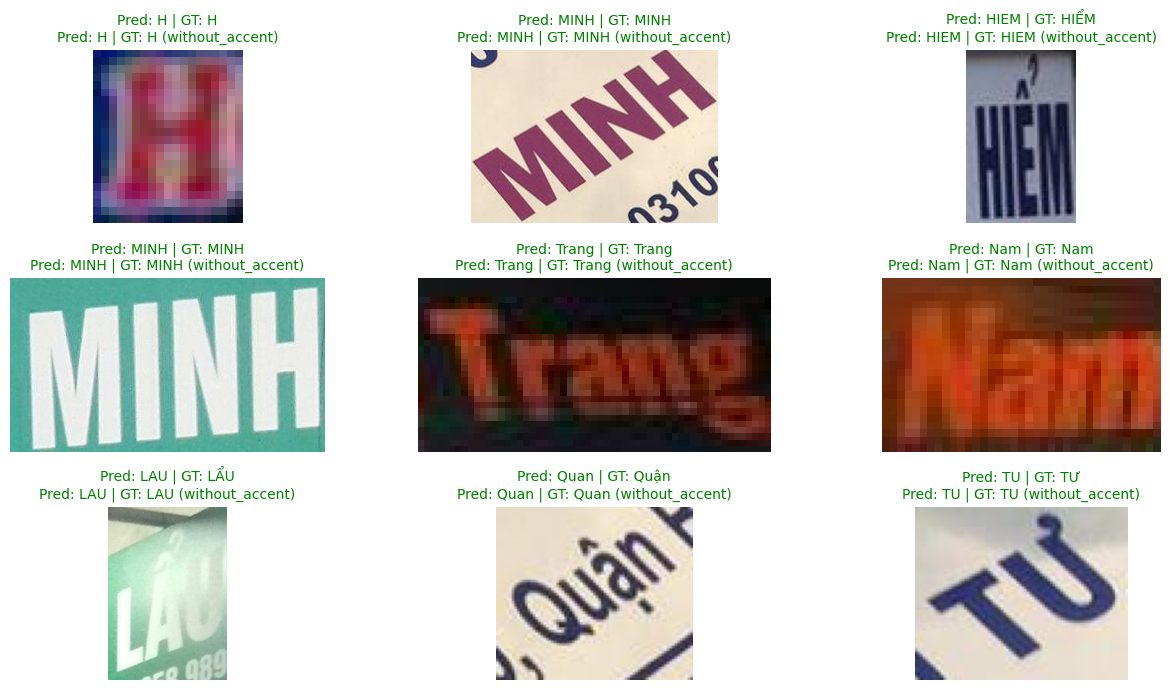

In [58]:
random.seed(42)
index = random.sample(np.arange(0, len(correct_prediction)).tolist(), k=9)
plot_prediction(index, correct_prediction, category_save='original', category='without_accent')

#### Text-line

In [26]:
vietline_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json', 
                                   category='recognize', 
                                   transforms=extractor)
vietline_dataloader = DataLoader(dataset=vietline_signboardtext, batch_size=1, shuffle=False)

In [27]:
# Evaluate vitstr vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
vietline_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vietline_dataloader,
                                                                                                              vitstr, 
                                                                                                              device,
                                                                                                              method='vitstr',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(converter, img2text))
print(f'Accuracy of vietsignboard with text-line: {vietline_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard with text-line: {total_samples}')
print(f'Total correct of vietsignboard with text-line: {total_correct}')
print(f'Total incorrect of vietsignboard with text-line: {total_samples - total_correct}')

without_accent


  3%|▎         | 37/1194 [00:04<02:01,  9.55it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg
batch is empty due to the unlabeled image!


  4%|▎         | 43/1194 [00:05<01:55,  9.96it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg
batch is empty due to the unlabeled image!
/kaggle/input/signboardtext/original_images/vietsignboard/levansy-69.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/languagecenter-1.jpg
batch is empty due to the unlabeled image!


 99%|█████████▉| 1183/1194 [02:23<00:01,  6.06it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [02:24<00:00,  8.25it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg
batch is empty due to the unlabeled image!
Accuracy of vietsignboard with text-line: 29.013698630136986
The number of empty batches: 90
Total samples of vietsignboard with text-line: 10950
Total correct of vietsignboard with text-line: 3177
Total incorrect of vietsignboard with text-line: 7773


In [98]:
set_seed(seed=42)
inputs = next(iter(viet_dataloader))[0]['text'].to(device)
print(f'Input shape: {inputs.shape}')
speed = measure_speed(vitstr, inputs)
flops = measure_flops(vitstr, inputs)
total_params, trainable_params, non_trainable_params = measure_params(vitstr)
print(f'Speed(ms): {speed:.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Input shape: torch.Size([1, 1, 224, 224])
Speed(ms): 9.80
FLOPS: 17.51
Total Params: 85.48
Trainable Params: 85.48
Non Trainable Params: 0.00


### SVTRv2

In [8]:
from tools.infer_rec import OpenRecognizer
from tools.engine.config import Config

class OpenOCRTransforms(object): 
    def __init__(self, transforms, ops, infer_aug=False):
        self.transforms = transforms
        self.ops = ops
        self.infer_aug = infer_aug
    def __call__(self, img):
        if not self.infer_aug: 
            assert isinstance(img, Image.Image)
        else: 
            if isinstance(img, Image.Image): 
                img = np.array(img)
        inputs = {'image': img}
        img = self.transforms(inputs, self.ops[1:])[0]
        if not isinstance(img, torch.Tensor): 
            img = torch.from_numpy(img)
        return img

In [9]:
# Download pretrained model SVTRv2-B
file_id_model = '1P56B_PVYBF649zUqQFShuAZC1XuNmUcL'
url_model = f'https://drive.google.com/uc?id={file_id_model}'
file_id_config = '1Ds-TilzI_2JIAomKyJS5RFCn-fU-UsOn'
url_config = f'https://drive.google.com/uc?id={file_id_config}'

gdown.download(url_model, 'SVTRv2-B.pth', quiet=False)
gdown.download(url_config, 'svtrv2_smtr_gtc_rctc.yml', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1P56B_PVYBF649zUqQFShuAZC1XuNmUcL
From (redirected): https://drive.google.com/uc?id=1P56B_PVYBF649zUqQFShuAZC1XuNmUcL&confirm=t&uuid=f6b099f9-1cca-4c91-9de1-9fe66a5c6e50
To: /kaggle/working/SVTRv2-B.pth
100%|██████████| 84.2M/84.2M [00:01<00:00, 42.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ds-TilzI_2JIAomKyJS5RFCn-fU-UsOn
To: /kaggle/working/svtrv2_smtr_gtc_rctc.yml
100%|██████████| 4.21k/4.21k [00:00<00:00, 6.55MB/s]


'svtrv2_smtr_gtc_rctc.yml'

In [10]:
config_file = '/kaggle/working/svtrv2_smtr_gtc_rctc.yml'
config = Config(config_file).cfg
config['Global']['character_dict_path'] = '/kaggle/working/OpenOCR/tools/utils/EN_symbol_dict.txt'
config['PostProcess']['character_dict_path'] = '/kaggle/working/OpenOCR/tools/utils/EN_symbol_dict.txt'
print(f"Model name {config['Architecture']['algorithm']}")

svtrv2 = OpenRecognizer(config)

Model name SVTRv2
[2025/10/17 10:17:30] openrec INFO: train from scratch


In [11]:
svtrv2_checkpoint = torch.load('/kaggle/working/SVTRv2-B.pth', map_location=device)
print(f"Epoch: {svtrv2_checkpoint['epoch']}")
print(f"Global Step: {svtrv2_checkpoint['global_step']}")

# Load pretrained model's weight
svtrv2.model.load_state_dict(svtrv2_checkpoint['state_dict'], strict=True)
svtrv2.post_process_class.only_gtc = True
svtrv2_transforms = OpenOCRTransforms(svtrv2.transform, svtrv2.ops)
svtrv2.model.eval().to(device)

Epoch: 18
Global Step: 114500


BaseRecognizer(
  (encoder): SVTRv2LNConvTwo33(
    (pope): POPatchEmbed(
      (patch_embed): Sequential(
        (0): ConvBNLayer(
          (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): GELU(approximate='none')
        )
        (1): ConvBNLayer(
          (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (stages): ModuleList(
      (0): SVTRStage(
        (blocks): Sequential(
          (0): ConvBlock(
            (norm1): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
            (mixer): Sequential(
              (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=4)
              (1): Conv2d

In [34]:
viet_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                   category='recognize', 
                                   transforms=svtrv2_transforms)
english_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                                      annotation_data='/kaggle/input/signboardtext/annotations.json',
                                      category='recognize',
                                      transforms=svtrv2_transforms)
vin_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin', 
                                  annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                  category='recognize',
                                  transforms=svtrv2_transforms)

viet_dataloader = DataLoader(dataset=viet_signboardtext, batch_size=1, shuffle=False)
english_dataloader = DataLoader(dataset=english_signboardtext, batch_size=1, shuffle=False)
vin_dataloader = DataLoader(dataset=vin_signboardtext, batch_size=1, shuffle=False)

In [35]:
# Evaluate svtrv2 vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
viet_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(viet_dataloader,
                                                                                                              svtrv2.model, 
                                                                                                              device,
                                                                                                              method='svtrv2',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(svtrv2.post_process_class, ))
print(f'Accuracy of vietsignboard: {viet_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard: {total_samples}')
print(f'Total correct of vietsignboard: {total_correct}')
print(f'Total incorrect of vietsignboard: {total_samples - total_correct}')

without_accent


 30%|███       | 359/1194 [03:51<11:51,  1.17it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg
batch is empty due to the unlabeled image!


 40%|███▉      | 475/1194 [05:05<06:51,  1.75it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg
batch is empty due to the unlabeled image!


 52%|█████▏    | 623/1194 [06:48<06:17,  1.51it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [13:03<00:00,  1.52it/s]

Accuracy of vietsignboard: 80.82118551719884
The number of empty batches: 5
Total samples of vietsignboard: 48637
Total correct of vietsignboard: 39309
Total incorrect of vietsignboard: 9328


In [37]:
# Evaluate svtrv2 vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
english_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(english_dataloader,
                                                                                                              svtrv2.model, 
                                                                                                              device,
                                                                                                              method='svtrv2',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(svtrv2.post_process_class, ))
print(f'Accuracy of english: {english_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of english: {total_samples}')
print(f'Total correct of english: {total_correct}')
print(f'Total incorrect of english: {total_samples - total_correct}')

without_accent


 47%|████▋     | 194/413 [00:32<00:43,  5.05it/s]/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 413/413 [01:10<00:00,  5.89it/s]

Accuracy of english: 78.33241908941305
The number of empty batches: 0
Total samples of english: 3646
Total correct of english: 2856
Total incorrect of english: 790


In [38]:
# Evaluate svtrv2 vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
vin_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vin_dataloader,
                                                                                                              svtrv2.model,  
                                                                                                              device,
                                                                                                              method='svtrv2',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(svtrv2.post_process_class, ))
print(f'Accuracy of vin: {vin_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vin: {total_samples}')
print(f'Total correct of vin: {total_correct}')
print(f'Total incorrect of vin: {total_samples - total_correct}')

without_accent


100%|██████████| 516/516 [04:25<00:00,  1.94it/s]

Accuracy of vin: 72.34465317919076
The number of empty batches: 0
Total samples of vin: 16608
Total correct of vin: 12015
Total incorrect of vin: 4593


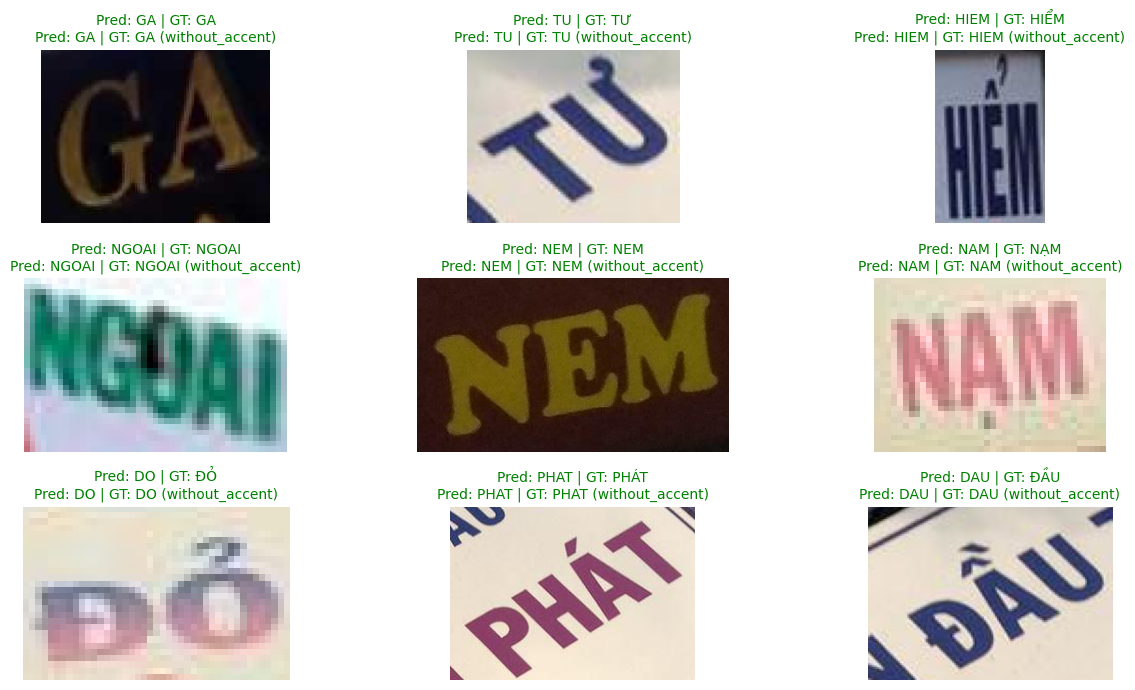

In [28]:
random.seed(42)
index = random.sample(np.arange(0, len(correct_prediction)).tolist(), k=9)
plot_prediction(index, correct_prediction, category_save='original', category='without_accent')

#### Text-line

In [12]:
vietline_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json', 
                                   category='recognize', 
                                   transforms=svtrv2_transforms)
vietline_dataloader = DataLoader(dataset=vietline_signboardtext, batch_size=1, shuffle=False)

In [13]:
# Evaluate svtrv2 vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
vietline_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vietline_dataloader,
                                                                                                              svtrv2.model, 
                                                                                                              device,
                                                                                                              method='svtrv2',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(svtrv2.post_process_class, ))
print(f'Accuracy of vietsignboard with text-line: {vietline_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard with text-line: {total_samples}')
print(f'Total correct of vietsignboard with text-line: {total_correct}')
print(f'Total incorrect of vietsignboard with text-line: {total_samples - total_correct}')

without_accent


  3%|▎         | 36/1194 [00:11<04:20,  4.45it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg
batch is empty due to the unlabeled image!


  4%|▎         | 42/1194 [00:12<04:15,  4.50it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg
batch is empty due to the unlabeled image!
/kaggle/input/signboardtext/original_images/vietsignboard/levansy-69.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/languagecenter-1.jpg
batch is empty due to the unlabeled image!


 99%|█████████▉| 1184/1194 [05:28<00:03,  3.27it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [05:31<00:00,  3.60it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg
batch is empty due to the unlabeled image!
Accuracy of vietsignboard with text-line: 65.64383561643835
The number of empty batches: 90
Total samples of vietsignboard with text-line: 10950
Total correct of vietsignboard with text-line: 7188
Total incorrect of vietsignboard with text-line: 3762


In [40]:
set_seed(seed=42)
inputs = torch.rand((1, 3, 32, 128)).to(device)
print(f'Input shape: {inputs.shape}')
speed = measure_speed(svtrv2.model, inputs)
flops = measure_flops(svtrv2.model, inputs)
total_params, trainable_params, non_trainable_params = measure_params(svtrv2.model)
print(f'Speed(ms): {speed:.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Input shape: torch.Size([1, 3, 32, 128])
Speed(ms): 18.81
FLOPS: 3.89
Total Params: 21.02
Trainable Params: 21.02
Non Trainable Params: 0.00


### SMTR

In [13]:
from tools.infer_rec import OpenRecognizer
from tools.engine.config import Config

In [14]:
# Download pretrained model SMTR
file_id_model = '16a9scNIaLLlG6Yj7weokXRDo4w9G5qDZ'
url_model = f'https://drive.google.com/uc?id={file_id_model}'
file_id_config = '15qNE5JYXidSHYJwdmG6Oc_foVtYkbFAo'
url_config = f'https://drive.google.com/uc?id={file_id_config}'

gdown.download(url_model, 'SMTR.pth', quiet=False)
gdown.download(url_config, 'focalsvtr_smtr.yml', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=16a9scNIaLLlG6Yj7weokXRDo4w9G5qDZ
From (redirected): https://drive.google.com/uc?id=16a9scNIaLLlG6Yj7weokXRDo4w9G5qDZ&confirm=t&uuid=188dac54-6d92-45a3-9f83-cd45e16d4791
To: /kaggle/working/SMTR.pth
100%|██████████| 63.4M/63.4M [00:00<00:00, 210MB/s]
Downloading...
From: https://drive.google.com/uc?id=15qNE5JYXidSHYJwdmG6Oc_foVtYkbFAo
To: /kaggle/working/focalsvtr_smtr.yml
100%|██████████| 3.92k/3.92k [00:00<00:00, 7.10MB/s]


'focalsvtr_smtr.yml'

In [34]:
config_file = '/kaggle/working/focalsvtr_smtr.yml'
config = Config(config_file).cfg
config['Global']['character_dict_path'] = '/kaggle/working/OpenOCR/tools/utils/EN_symbol_dict.txt'
config['Eval']['dataset']['transforms'][1]['ARLabelEncode']['character_dict_path'] = '/kaggle/working/OpenOCR/tools/utils/EN_symbol_dict.txt'
config['PostProcess']['character_dict_path'] = '/kaggle/working/OpenOCR/tools/utils/EN_symbol_dict.txt'

smtr = OpenRecognizer(config)

[2025/10/17 09:40:06] openrec INFO: train from scratch


In [35]:
smtr_checkpoint = torch.load('/kaggle/working/SMTR.pth', map_location=device)
print(f"Epoch: {smtr_checkpoint['epoch']}")
print(f"Global Step: {smtr_checkpoint['global_step']}")

# Load pretrained model's weight
smtr.model.load_state_dict(smtr_checkpoint['state_dict'], strict=True)
smtr_transforms = OpenOCRTransforms(smtr.transform, smtr.ops, smtr.model.decoder.infer_aug)
smtr.model.eval().to(device)

Epoch: 18
Global Step: 59976


BaseRecognizer(
  (encoder): FocalSVTR(
    (patch_embed): Sequential(
      (0): ConvBNLayer(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (norm): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
      (1): ConvBNLayer(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (norm): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0): BasicLayer(
        dim=96, input_resolution=[8, 32], depth=6
        (blocks): ModuleList(
          (0): FocalNetBlock(
            dim=96, input_resolution=[8, 32], mlp_ratio=4.0
            (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (modulation): FocalModulation(
              dim=

(61, 894, 3)


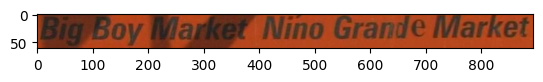

In [31]:
text = cv2.imread('/kaggle/working/uber.jpg')
text = cv2.cvtColor(text, cv2.COLOR_BGR2RGB)
print(text.shape)
plt.imshow(text)
plt.show()

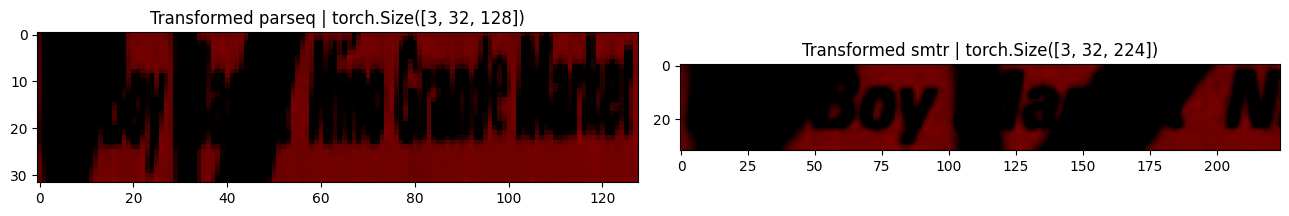

In [37]:
text_smtr = smtr_transforms(text) # Split three sub-images 
first_text_smtr = text_smtr[0, :, :, :] # Get first sub-images
text_parseq = img_transform(Image.fromarray(text))

plt.figure(figsize=(13, 7))
plt.subplot(1, 2, 1)
plt.imshow(text_parseq.permute(1, 2, 0).cpu().numpy())
plt.title(f'Transformed parseq | {text_parseq.shape}')
plt.subplot(1, 2, 2)
plt.imshow(first_text_smtr.permute(1, 2, 0).cpu().numpy())
plt.title(f'Transformed smtr | {first_text_smtr.shape}')

plt.tight_layout()
plt.show()

In [115]:
# set_seed(seed=42)
# print(x.shape)
# logits = smtr.model(torch.from_numpy(text_smtr[0]))
# pred = logits.detach().cpu().numpy()
# pred_idx = pred.argmax(axis=2)
# smtr.post_process_class.decode(pred_idx)

In [38]:
# pred_parseq, _ = predict_one_image(parseq, text_parseq.unsqueeze(dim=0).to(device), '', method='parseq',
#                                   category='without_accent')
# pred_smtr, _ = predict_one_image(smtr.model, text_smtr.to(device), '', method='smtr',
#                                 category='without_accent',postprocess = (smtr.post_process_class, ))
# pred_svtrv2, _ = predict_one_image(svtrv2.model, text_smtr.unsqueeze(dim=0), '', method='svtrv2',
#                                 category='without_accent',post_process_class=svtrv2.post_process_class)

In [39]:
# print(f'Pred: {pred_parseq} | Len: {len(pred_parseq)}')
# print(f'Pred: {pred_smtr} | Len: {len(pred_smtr)}')
# print(pred_svtrv2)

Pred: BigSoyMarketNinoGranket | Len: 23
Pred: BigBoyMarketNinoGrandeMarket | Len: 28


In [15]:
viet_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                   category='recognize', 
                                   transforms=smtr_transforms)
english_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                                      annotation_data='/kaggle/input/signboardtext/annotations.json',
                                      category='recognize',
                                      transforms=smtr_transforms)
vin_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin', 
                                  annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                  category='recognize',
                                  transforms=smtr_transforms)

viet_dataloader = DataLoader(dataset=viet_signboardtext, batch_size=1, shuffle=False)
english_dataloader = DataLoader(dataset=english_signboardtext, batch_size=1, shuffle=False)
vin_dataloader = DataLoader(dataset=vin_signboardtext, batch_size=1, shuffle=False)

In [24]:
# Evaluate smtr vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
viet_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(viet_dataloader,
                                                                                                              smtr.model, 
                                                                                                              device,
                                                                                                              method='smtr',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(smtr.post_process_class, ))
print(f'Accuracy of vietsignboard: {viet_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard: {total_samples}')
print(f'Total correct of vietsignboard: {total_correct}')
print(f'Total incorrect of vietsignboard: {total_samples - total_correct}')

without_accent


 30%|███       | 359/1194 [05:34<16:18,  1.17s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg
batch is empty due to the unlabeled image!


 40%|███▉      | 475/1194 [07:19<09:24,  1.27it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg
batch is empty due to the unlabeled image!


 52%|█████▏    | 623/1194 [09:47<08:56,  1.06it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [18:57<00:00,  1.05it/s]

Accuracy of vietsignboard: 79.57933260686309
The number of empty batches: 5
Total samples of vietsignboard: 48637
Total correct of vietsignboard: 38705
Total incorrect of vietsignboard: 9932


In [25]:
# Evaluate smtr vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
english_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(english_dataloader,
                                                                                                              smtr.model, 
                                                                                                              device,
                                                                                                              method='smtr',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(smtr.post_process_class, ))
print(f'Accuracy of english: {english_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of english: {total_samples}')
print(f'Total correct of english: {total_correct}')
print(f'Total incorrect of english: {total_samples - total_correct}')

without_accent


100%|██████████| 413/413 [01:40<00:00,  4.12it/s]

Accuracy of english: 76.76906198573779
The number of empty batches: 0
Total samples of english: 3646
Total correct of english: 2799
Total incorrect of english: 847


In [26]:
# Evaluate svtrv2 vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
vin_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vin_dataloader,
                                                                                                              smtr.model, 
                                                                                                              device,
                                                                                                              method='smtr',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(smtr.post_process_class, ))
print(f'Accuracy of vin: {vin_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vin: {total_samples}')
print(f'Total correct of vin: {total_correct}')
print(f'Total incorrect of vin: {total_samples - total_correct}')

without_accent


 32%|███▏      | 167/516 [02:19<04:40,  1.25it/s]/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 516/516 [06:37<00:00,  1.30it/s]

Accuracy of vin: 70.64065510597302
The number of empty batches: 0
Total samples of vin: 16608
Total correct of vin: 11732
Total incorrect of vin: 4876


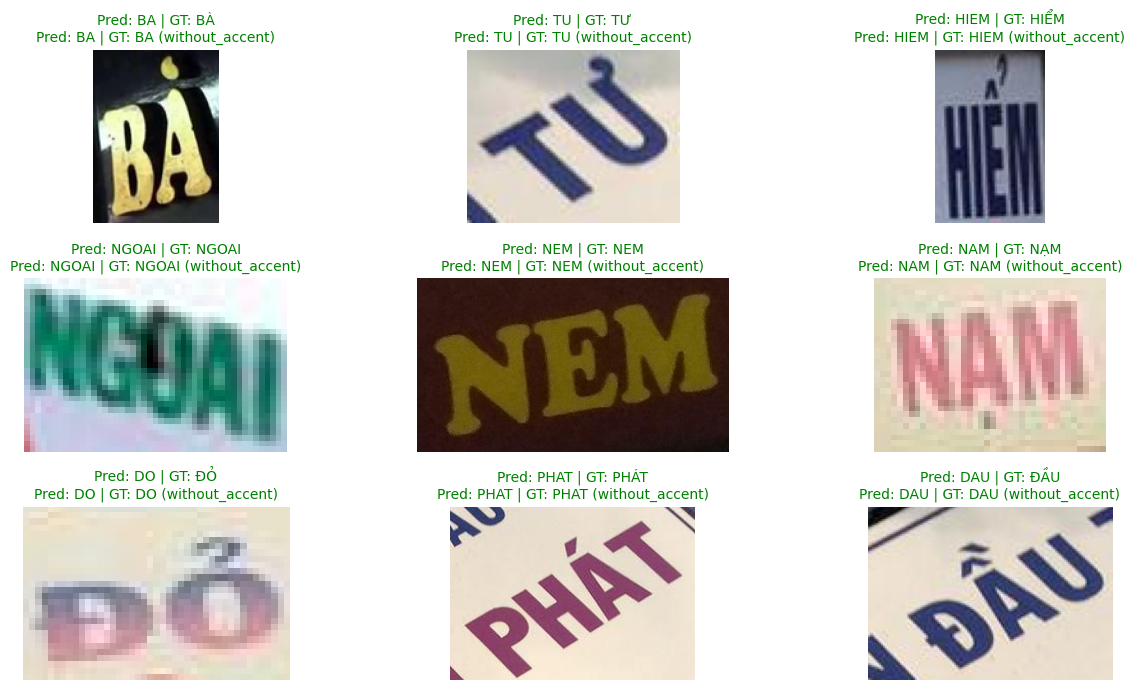

In [17]:
random.seed(42)
index = random.sample(np.arange(0, len(correct_prediction)).tolist(), k=9)
plot_prediction(index, correct_prediction, category_save='original', category='without_accent')

#### Text-line

In [48]:
vietline_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json', 
                                   category='recognize', 
                                   transforms=smtr_transforms)
vietline_dataloader = DataLoader(dataset=vietline_signboardtext, batch_size=1, shuffle=False)

In [45]:
# Evaluate smtr vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
vietline_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vietline_dataloader,
                                                                                                              smtr.model, 
                                                                                                              device,
                                                                                                              method='smtr',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(smtr.post_process_class, ))
print(f'Accuracy of vietsignboard with text-line: {vietline_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard with text-line: {total_samples}')
print(f'Total correct of vietsignboard with text-line: {total_correct}')
print(f'Total incorrect of vietsignboard with text-line: {total_samples - total_correct}')

without_accent


  3%|▎         | 37/1194 [00:14<05:01,  3.83it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg
batch is empty due to the unlabeled image!


  4%|▎         | 42/1194 [00:15<05:43,  3.35it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg
batch is empty due to the unlabeled image!
/kaggle/input/signboardtext/original_images/vietsignboard/levansy-69.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/languagecenter-1.jpg
batch is empty due to the unlabeled image!


 99%|█████████▉| 1184/1194 [07:41<00:04,  2.34it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [07:45<00:00,  2.57it/s]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg
batch is empty due to the unlabeled image!
Accuracy of vietsignboard with text-line: 64.53881278538813
The number of empty batches: 90
Total samples of vietsignboard with text-line: 10950
Total correct of vietsignboard with text-line: 7067
Total incorrect of vietsignboard with text-line: 3883


In [29]:
set_seed(seed=42)
inputs = torch.rand((1, 3, 32, 128)).to(device)
print(f'Input shape: {inputs.shape}')
speed = measure_speed(smtr.model, inputs)
flops = measure_flops(smtr.model, inputs)
total_params, trainable_params, non_trainable_params = measure_params(smtr.model)
print(f'Speed(ms): {speed:.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Input shape: torch.Size([1, 3, 32, 128])
Speed(ms): 23.47
FLOPS: 2.60
Total Params: 15.82
Trainable Params: 15.82
Non Trainable Params: 0.00


### CDistNet

In [8]:
!pip install -q mmengine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.7/452.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 89.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 16.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0

In [9]:
from cdistnet.model.model import build_CDistNet
from mmengine.config import Config
from cdistnet.model.translator import Translator
import codecs
from openrec.postprocess.ar_postprocess import ARLabelDecode

In [50]:
class CDistNetLabelDecode(ARLabelDecode):
    def add_special_char(self, dict_character):
        # KHÔNG thêm special tokens
        return dict_character

class CDistNetTransforms(object):
    def __init__(self, cfg): 
        self.rgb2gray = cfg.rgb2gray
        self.width = cfg.width
        self.height = cfg.height
    def __call__(self, img):
        assert isinstance(img, Image.Image)
        if self.rgb2gray: 
            image = img.convert('L')
        else: 
            image = img.convert('RGB')
        assert image is not None
        image = image.resize((self.width, self.height), Image.Resampling.LANCZOS)
        image = np.array(image)

        if self.rgb2gray: 
            image = np.expand_dims(image, -1)

        image = image.transpose((2, 0, 1))
        image = image.astype(np.float32) / 128. - 1.
        image = torch.from_numpy(image)
    
        image = image.contiguous()
        return image

In [11]:
# Download pretrained model CDistNet
file_id = '1tmsaY9iiymqFGbY1Eq_tdzHegXjYW1qc'
url = f'https://drive.google.com/uc?id={file_id}'

gdown.download(url, 'CDistNet.pth', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1tmsaY9iiymqFGbY1Eq_tdzHegXjYW1qc
From (redirected): https://drive.google.com/uc?id=1tmsaY9iiymqFGbY1Eq_tdzHegXjYW1qc&confirm=t&uuid=507cf7a7-71d1-4637-8d5a-bd7c70d5ef5e
To: /kaggle/working/CDistNet.pth
100%|██████████| 303M/303M [00:02<00:00, 134MB/s]  


'CDistNet.pth'

In [12]:
# Load state_dict for checkpoint
cdistnet_checkpoint = torch.load('/kaggle/working/CDistNet.pth', map_location=device)

# Initialize cdisnet's architecture
cdistnet_config = Config.fromfile('/kaggle/working/CDistNet/configs/CDistNet_config.py')
cdistnet_config['dst_vocab'] = '/kaggle/working/CDistNet/cdistnet/utils/dict_36.txt'
cdistnet_config['dst_vocab_size'] = 40
cdistnet = build_CDistNet(cdistnet_config)
# Load pretrained checkpoint to model cdisnet
cdistnet.load_state_dict(cdistnet_checkpoint, strict=True)
cdistnet.eval().to(device)

CDistNet(
  (visual_branch): VIS_Pre(
    (transform): TPS_SpatialTransformerNetwork(
      (LocalizationNetwork): LocalizationNetwork(
        (conv): Sequential(
          (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (6): ReLU(inplace=True)
          (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (10): ReLU

In [13]:
cdistnet_config.test.device = device
translator = Translator(cdistnet_config, cdistnet)
cdistnet_converter = CDistNetLabelDecode(character_dict_path=cdistnet_config['dst_vocab'],
                         use_space_char=False)
cdistnet_transforms = CDistNetTransforms(cdistnet_config)

In [14]:
viet_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                   category='recognize', 
                                   transforms=cdistnet_transforms)
english_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/english',
                                      annotation_data='/kaggle/input/signboardtext/annotations.json',
                                      category='recognize',
                                      transforms=cdistnet_transforms)
vin_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vin', 
                                  annotation_data='/kaggle/input/signboardtext/annotations.json', 
                                  category='recognize',
                                  transforms=cdistnet_transforms)

viet_dataloader = DataLoader(dataset=viet_signboardtext, batch_size=1, shuffle=False)
english_dataloader = DataLoader(dataset=english_signboardtext, batch_size=1, shuffle=False)
vin_dataloader = DataLoader(dataset=vin_signboardtext, batch_size=1, shuffle=False)

In [32]:
# Evaluate smtr vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
viet_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(viet_dataloader,
                                                                                                              translator, 
                                                                                                              device,
                                                                                                              method='cdistnet',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(cdistnet_converter, ))
print(f'Accuracy of vietsignboard: {viet_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard: {total_samples}')
print(f'Total correct of vietsignboard: {total_correct}')
print(f'Total incorrect of vietsignboard: {total_samples - total_correct}')

without_accent


 30%|███       | 359/1194 [12:00<33:18,  2.39s/it]  

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-11.jpg
batch is empty due to the unlabeled image!


 40%|███▉      | 475/1194 [15:45<20:10,  1.68s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-3.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-46.jpg
batch is empty due to the unlabeled image!


 52%|█████▏    | 623/1194 [21:04<20:40,  2.17s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/milkteastore-5.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [40:37<00:00,  2.04s/it]

Accuracy of vietsignboard: 63.25431256039641
The number of empty batches: 5
Total samples of vietsignboard: 48637
Total correct of vietsignboard: 30765
Total incorrect of vietsignboard: 17872


In [33]:
# Evaluate smtr vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
english_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(english_dataloader,
                                                                                                              translator, 
                                                                                                              device,
                                                                                                              method='cdistnet',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(cdistnet_converter, ))
print(f'Accuracy of english: {english_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of english: {total_samples}')
print(f'Total correct of english: {total_correct}')
print(f'Total incorrect of english: {total_samples - total_correct}')

without_accent


100%|██████████| 413/413 [04:07<00:00,  1.67it/s]

Accuracy of english: 68.12945693911135
The number of empty batches: 0
Total samples of english: 3646
Total correct of english: 2484
Total incorrect of english: 1162


In [35]:
# Evaluate svtrv2 vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
vin_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vin_dataloader,
                                                                                                             translator, 
                                                                                                              device,
                                                                                                              method='cdistnet',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(cdistnet_converter, ))
print(f'Accuracy of vin: {vin_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vin: {total_samples}')
print(f'Total correct of vin: {total_correct}')
print(f'Total incorrect of vin: {total_samples - total_correct}')

without_accent


 11%|█         | 57/516 [01:23<19:10,  2.51s/it]/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
100%|██████████| 516/516 [12:38<00:00,  1.47s/it]

Accuracy of vin: 56.394508670520224
The number of empty batches: 0
Total samples of vin: 16608
Total correct of vin: 9366
Total incorrect of vin: 7242


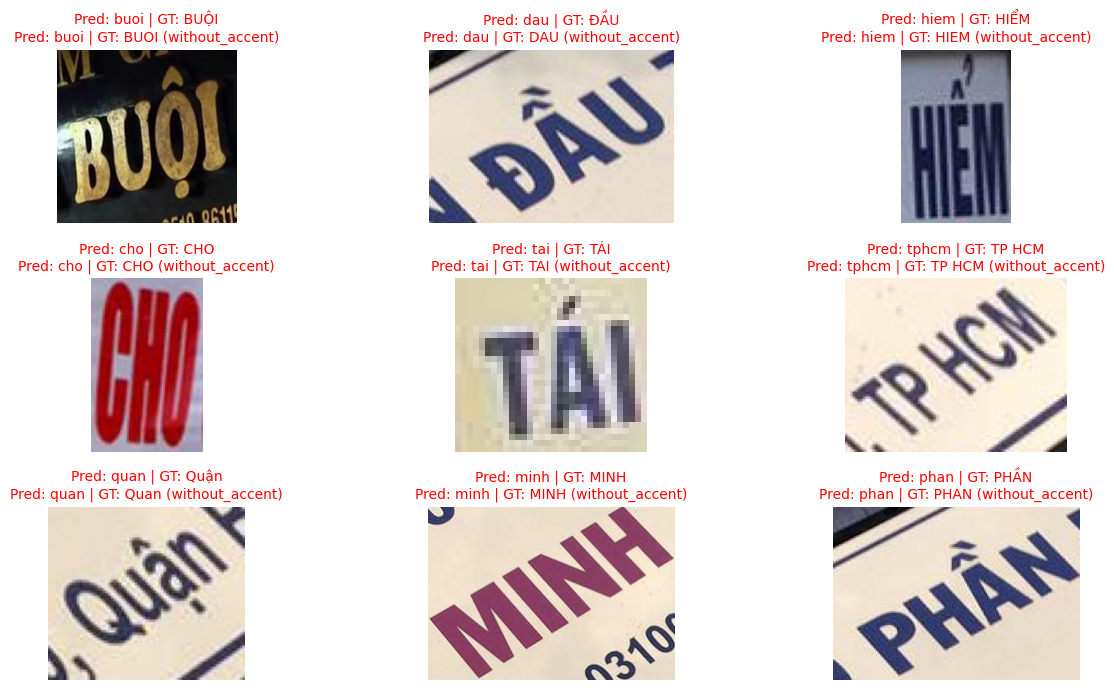

In [36]:
random.seed(42)
index = random.sample(np.arange(0, len(correct_prediction)).tolist(), k=9)
plot_prediction(index, correct_prediction, category_save='original', category='without_accent')

#### Text-line

In [34]:
vietline_signboardtext = SignboardText(image_data='/kaggle/input/signboardtext/original_images/vietsignboard', 
                                   annotation_data='/kaggle/input/signboardtext/annotations_line.json', 
                                   category='recognize', 
                                   transforms=cdistnet_transforms)
vietline_dataloader = DataLoader(dataset=vietline_signboardtext, batch_size=1, shuffle=False)

In [35]:
# Evaluate cdistnet vietnamese model on vietsignboard corpus 
set_seed(seed=42) 
vietline_accuracy, batch_empty, correct_prediction, incorrect_prediction, total_samples, total_correct = evaluate(vietline_dataloader,
                                                                                                              translator, 
                                                                                                              device,
                                                                                                              method='cdistnet',
                                                                                                             category='without_accent',
                                                                                                             postprocess=(cdistnet_converter, ))
print(f'Accuracy of vietsignboard with text-line: {vietline_accuracy}')
print(f'The number of empty batches: {batch_empty}')
print(f'Total samples of vietsignboard with text-line: {total_samples}')
print(f'Total correct of vietsignboard with text-line: {total_correct}')
print(f'Total incorrect of vietsignboard with text-line: {total_samples - total_correct}')

without_accent


  3%|▎         | 36/1194 [00:48<20:26,  1.06s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-60.jpg
batch is empty due to the unlabeled image!


  3%|▎         | 40/1194 [00:55<34:23,  1.79s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/else-135.jpg
batch is empty due to the unlabeled image!
/kaggle/input/signboardtext/original_images/vietsignboard/levansy-69.jpg
batch is empty due to the unlabeled image!


...

/kaggle/input/signboardtext/original_images/vietsignboard/languagecenter-1.jpg
batch is empty due to the unlabeled image!


 99%|█████████▉| 1183/1194 [26:41<00:20,  1.90s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/levansy-12.jpg
batch is empty due to the unlabeled image!


100%|██████████| 1194/1194 [26:56<00:00,  1.35s/it]

/kaggle/input/signboardtext/original_images/vietsignboard/else-118.jpg
batch is empty due to the unlabeled image!
Accuracy of vietsignboard with text-line: 42.42922374429224
The number of empty batches: 90
Total samples of vietsignboard with text-line: 10950
Total correct of vietsignboard with text-line: 4646
Total incorrect of vietsignboard with text-line: 6304


In [75]:
from CDistNet.cdistnet.model.translator import Beam
def prepare_beam_dec_seq(inst_dec_beams, len_dec_seq, device):
    '''
    prepare beam_tgt for decoder
    :param inst_dec_beams: class beam(num:batch_size)
    :param len_dec_seq: max_len(beam search len)
    :return: beam_tgt
    '''
    # init beams as 2 for start
    dec_partial_seq = [b.get_current_state() for b in inst_dec_beams if not b.done]
    dec_partial_seq = torch.stack(dec_partial_seq).to(device)
    dec_partial_seq = dec_partial_seq.view(-1, len_dec_seq)
    return dec_partial_seq

def generate_tgt(images, cdistnet_config, cdistnet):
    n_bm = cdistnet_config.beam_size
    src_enc,memory_key_padding_mask  = cdistnet.visual_branch(images)
    n_inst, len_s, d_h = src_enc.permute(1, 0, 2).size()
    inst_dec_beams = [Beam(n_bm, device=device) for _ in range(n_inst)]
    dec_seq = prepare_beam_dec_seq(inst_dec_beams, n_bm, device)

    return dec_seq

In [49]:
set_seed(seed=42)
inputs = torch.rand((1, 3, 32,128)).to(device)
tgt = generate_tgt(inputs, cdistnet_config, cdistnet)
print(f'Input shape: {inputs.shape}')
speed = measure_speed(translator.translate_batch, inputs)
flops = measure_flops(cdistnet, (inputs, tgt))
total_params, trainable_params, non_trainable_params = measure_params(cdistnet)
print(f'Speed(ms): {speed:.2f}')
print(f'FLOPS: {flops:.2f}')
print(f'Total Params: {total_params:.2f}')
print(f'Trainable Params: {trainable_params:.2f}')
print(f'Non Trainable Params: {non_trainable_params:.2f}')

Input shape: torch.Size([1, 3, 32, 128])
Speed(ms): 120.33
FLOPS: 4.77
Total Params: 65.46
Trainable Params: 65.46
Non Trainable Params: 0.00
